<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/06_Airbnb_Berlin_Model_Selection_Finetuning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [290]:
# !pip install missingno
# !pip install geopy
# !pip install xgboost

In [291]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [292]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [293]:
df_Model_Selection = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Model_Selection.pkl')
df_Model_Selection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23536 non-null  float64
 1   Checkin Rating         23536 non-null  float64
 2   Cleanliness Rating     23536 non-null  float64
 3   Communication Rating   23536 non-null  float64
 4   Latitude               23536 non-null  float64
 5   Location Rating        23536 non-null  float64
 6   Longitude              23536 non-null  float64
 7   Overall Rating         23536 non-null  float64
 8   Value Rating           23536 non-null  float64
 9   Host Response Time     23536 non-null  int64  
 10  Is Superhost           23536 non-null  bool   
 11  Neighborhood Group     23536 non-null  int64  
 12  Is Exact Location      23536 non-null  bool   
 13  Room Type              23536 non-null  int64  
 14  Instant Bookable       23536 non-null  bool   
 15  Ac

In [294]:
df = df_Model_Selection.copy()
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]

# Model Selection and Fine Tuning

## Metrics

We reached this stage with only the most important feature bases on 3 out of 4 models (Review Feature Selection stage )

In [295]:
df.head()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Latitude,Location Rating,Longitude,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Is Exact Location,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
0,10.0,10.0,10.0,10.0,52.54851,9.0,13.40455,100.0,10.0,2,False,6,True,1,False,2.000000,1.0,1.0,1.0,2.000000,7.0,0,0,5.1,17,17.0
1,9.0,9.0,9.0,9.0,52.53500,10.0,13.41758,92.0,9.0,2,False,6,True,0,False,4.000000,1.0,2.0,2.0,1.727273,144.0,0,0,3.7,17,90.0
2,10.0,10.0,10.0,10.0,52.54316,10.0,13.41509,96.0,10.0,4,True,6,True,1,False,2.000000,1.0,2.0,1.0,2.000000,229.0,0,0,4.6,16,33.0
3,10.0,10.0,10.0,10.0,52.53303,10.0,13.41605,100.0,10.0,2,False,6,False,0,False,3.636364,4.0,7.0,5.0,6.000000,6.0,0,0,3.5,16,180.0
4,10.0,9.0,10.0,10.0,52.54785,9.0,13.40556,93.0,9.0,2,False,6,True,0,False,1.000000,0.0,1.0,1.0,2.454545,23.0,0,0,5.0,16,70.0


In [296]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accuracy Rating,23460.0,9.659614,0.682676,2.00000,9.454545,10.000000,10.000000,10.00000
Checkin Rating,23460.0,9.709238,0.645831,2.00000,9.636364,10.000000,10.000000,10.00000
Cleanliness Rating,23460.0,9.319216,0.949321,2.00000,9.000000,9.636364,10.000000,10.00000
Communication Rating,23460.0,9.732330,0.626641,2.00000,9.818182,10.000000,10.000000,10.00000
Latitude,23460.0,52.509878,0.031272,52.34580,52.489130,52.509200,52.532660,52.65167
Location Rating,23460.0,9.531822,0.692451,2.00000,9.000000,10.000000,10.000000,10.00000
Longitude,23460.0,13.406264,0.058577,13.09718,13.375905,13.416640,13.439542,13.75764
Overall Rating,23460.0,94.593614,6.968951,20.00000,92.727273,96.363636,100.000000,100.00000
Value Rating,23460.0,9.399849,0.775066,2.00000,9.000000,9.636364,10.000000,10.00000
Host Response Time,23460.0,2.208483,1.332796,0.00000,1.000000,2.000000,4.000000,4.00000


In [297]:
df.corr()

,Accuracy Rating,Checkin Rating,Cleanliness Rating,Communication Rating,Latitude,Location Rating,Longitude,Overall Rating,Value Rating,Host Response Time,Is Superhost,Neighborhood Group,Is Exact Location,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Host Since From Now,Price
Accuracy Rating,1.000000,0.494658,0.520012,0.527813,-0.006024,0.374249,0.009237,0.658492,0.592437,0.054185,0.158737,0.012897,0.021651,-0.026092,-0.035600,-0.006472,-0.002469,-0.060814,-0.004446,0.060590,0.076515,-0.008278,-0.019713,-0.013128,0.034186,0.025940
Checkin Rating,0.494658,1.000000,0.377434,0.617458,-0.018087,0.318516,0.002869,0.508561,0.439422,0.070801,0.136202,0.017329,0.032987,-0.001975,-0.021822,-0.002863,0.018106,-0.012712,0.016051,0.025975,0.071005,0.018610,-0.013415,0.013583,0.024229,0.030924
Cleanliness Rating,0.520012,0.377434,1.000000,0.403526,0.002449,0.299939,-0.003473,0.669369,0.525932,0.113654,0.192065,0.026066,0.011969,-0.059652,-0.030771,0.005231,0.030714,-0.005705,0.030603,0.011751,0.092094,0.044184,-0.015248,0.015729,0.040809,0.112347
Communication Rating,0.527813,0.617458,0.403526,1.000000,-0.011097,0.343720,-0.000398,0.576533,0.484296,0.058162,0.137632,0.016944,0.017687,-0.011796,-0.035048,-0.003548,0.008673,-0.032088,0.004375,0.030352,0.056386,-0.008045,-0.012679,-0.005736,0.041977,0.022504
Latitude,-0.006024,-0.018087,0.002449,-0.011097,1.000000,-0.008730,-0.110910,-0.019323,-0.015996,0.029208,0.009326,-0.138954,-0.002894,-0.024760,0.010755,0.027487,0.002291,0.008513,0.010746,-0.009531,0.039804,-0.010970,0.010504,0.036200,-0.009724,0.032962
Location Rating,0.374249,0.318516,0.299939,0.343720,-0.008730,1.000000,0.002880,0.411841,0.415568,0.082373,0.104812,-0.065141,0.005391,-0.031592,-0.005305,0.000873,-0.009759,-0.054031,-0.009346,0.042884,0.073756,-0.040467,-0.117333,-0.187584,0.031001,0.083622
Longitude,0.009237,0.002869,-0.003473,-0.000398,-0.110910,0.002880,1.000000,0.018219,0.018497,-0.043979,-0.020847,-0.033755,-0.014180,0.015323,-0.016771,-0.004527,-0.001012,-0.013416,0.014366,0.012450,-0.022952,0.004150,-0.146376,-0.159629,0.042792,-0.043336
Overall Rating,0.658492,0.508561,0.669369,0.576533,-0.019323,0.411841,0.018219,1.000000,0.681791,0.023671,0.155160,0.014339,0.007996,-0.011572,-0.050631,-0.030483,0.006682,-0.070626,-0.018160,0.063386,-0.001600,0.000699,-0.015326,-0.013084,0.020665,0.051339
Value Rating,0.592437,0.439422,0.525932,0.484296,-0.015996,0.415568,0.018497,0.681791,1.000000,-0.003981,0.127767,0.023281,0.002800,0.073251,-0.046628,-0.078673,-0.022460,-0.094301,-0.051600,0.068492,0.016529,-0.023754,0.003883,0.009349,0.009589,-0.069281
Host Response Time,0.054185,0.070801,0.113654,0.058162,0.029208,0.082373,-0.043979,0.023671,-0.003981,1.000000,0.364287,0.007908,0.047358,-0.050116,0.258269,0.122286,0.050097,0.157187,0.149647,-0.115408,0.363463,0.156290,-0.043496,0.061375,-0.043366,0.159898


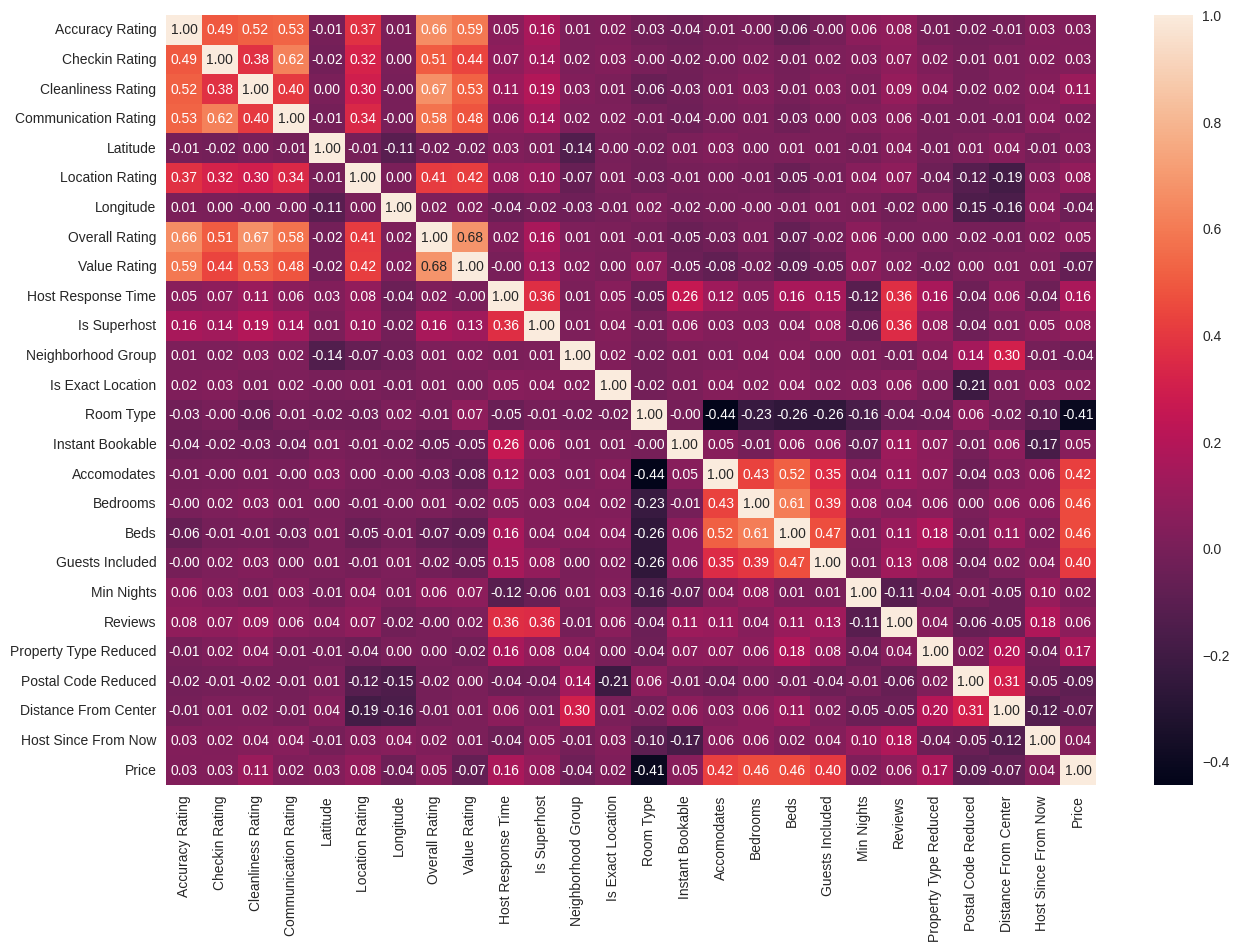

In [298]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", annot_kws={"size":10})
plt.show()

## Create and Train the Model

In [299]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import sklearn.metrics as metrics

In [300]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Price', inplace=False)
y = df['Price']

# Split into train+val and test sets (80% train+val, 20% test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split train+val into train and val sets (75% train, 25% val from the train+val set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

## Regression Models

In [301]:
models_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])
models_list.style.set_properties(subset=['model'], **{'text-align': 'left'})

,model,MAE,MSE,RMSE,RMSLE,R²


In [302]:
def regressionMetrics(y, y_pred):
    res = {
          'MAE': metrics.mean_absolute_error(y, y_pred),
          'MSE': metrics.mean_squared_error(y, y_pred),
          'RMSE': np.sqrt(metrics.mean_squared_error(y, y_pred)),
          'RMSLE': np.sqrt(metrics.mean_squared_log_error(np.abs(y), np.abs(y_pred))),
          'R²': metrics.r2_score(y, y_pred)
          }

    return res

### Linear Regression

In [303]:
# create and train model
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

LinearRegression()

In [304]:
# make predictions on the validation set
y_val_pred_LR = model_LR.predict(X_val)

In [305]:
regressionMetrics(y_val, y_val_pred_LR)

{'MAE': 21.93920367570779,
 'MSE': 1396.5806563507833,
 'RMSE': np.float64(37.37085303215306),
 'RMSLE': np.float64(0.48928295603354705),
 'R²': 0.4149915991944778}

In [306]:
model_dict = {"model":"LinearRegression"}
model_dict.update(regressionMetrics(y_val, y_val_pred_LR))
model_dict
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)

In [307]:
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992


<Axes: xlabel='Price'>

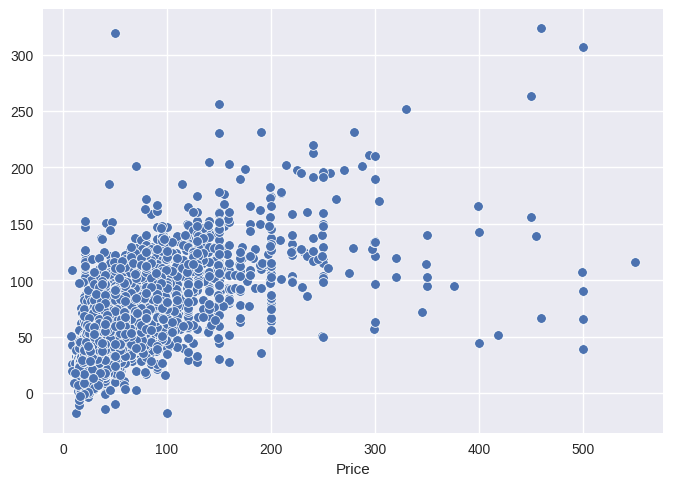

In [308]:
sns.scatterplot(x=y_val, y=y_val_pred_LR)

### *Decision Tree Regressor*

In [309]:
model_DTR = DecisionTreeRegressor(random_state=42)
model_DTR.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [310]:
# make predictions on the validation set
y_val_pred_DTR = model_DTR.predict(X_val)

In [311]:
regressionMetrics(y_val, y_val_pred_DTR)

{'MAE': 27.21014492753623,
 'MSE': 2504.02600170503,
 'RMSE': np.float64(50.04024382139869),
 'RMSLE': np.float64(0.5452624337922288),
 'R²': -0.048902002309394454}

In [312]:
model_dict = {"model":"DecisionTree"}
model_dict.update(regressionMetrics(y_val, y_val_pred_DTR))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
# models_list.style.set_properties(**{'text-align': 'left'})
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902


<Axes: xlabel='Price'>

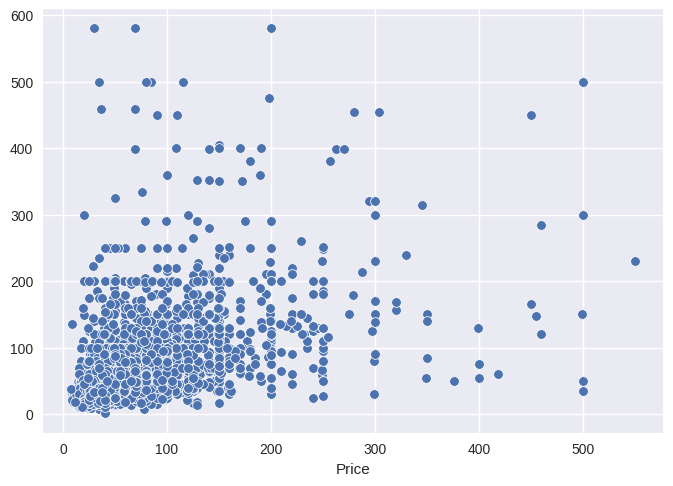

In [313]:
sns.scatterplot(x=y_val, y=y_val_pred_DTR)

### RandomForestRegressor

In [314]:
model_RFR = RandomForestRegressor(random_state=42)
model_RFR.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [315]:
# Make predictions on the validation set
y_val_pred_RFR = model_RFR.predict(X_val)

In [316]:
regressionMetrics(y_val, y_val_pred_RFR)

{'MAE': 19.85904092071611,
 'MSE': 1178.1982316283036,
 'RMSE': np.float64(34.3248923032295),
 'RMSLE': np.float64(0.40913067493624933),
 'R²': 0.506468988967834}

In [317]:
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_RFR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469


<Axes: xlabel='Price'>

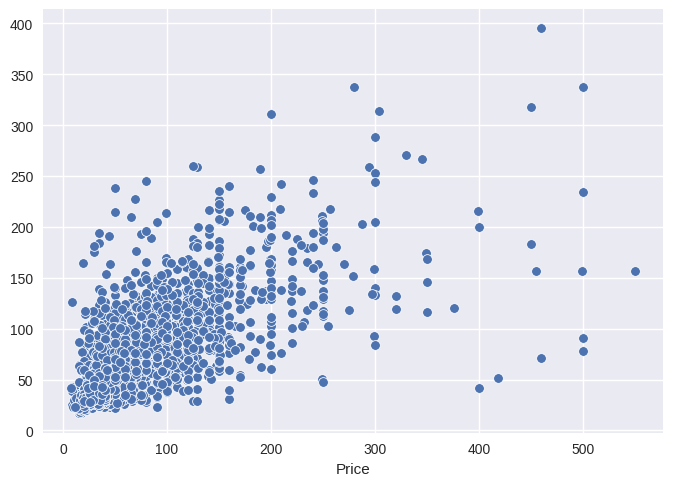

In [318]:
sns.scatterplot(x=y_val, y=y_val_pred_RFR)

### Adaptive Boosting (ADABoost)

In [319]:
model_ADABoost = AdaBoostRegressor(random_state=42)
model_ADABoost.fit(X_train, y_train)

AdaBoostRegressor(random_state=42)

In [320]:
# Make predictions on the validation set
y_val_pred_ADABoost = model_ADABoost.predict(X_val)

In [321]:
regressionMetrics(y_val, y_val_pred_ADABoost)

{'MAE': 31.358416971337533,
 'MSE': 2171.1763590290675,
 'RMSE': np.float64(46.59588349874984),
 'RMSLE': np.float64(0.5853373018475341),
 'R²': 0.09052412842289725}

Update model list with **Adaptive Boosting (ADABoost)** model results

In [322]:
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_ADABoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524


<Axes: xlabel='Price'>

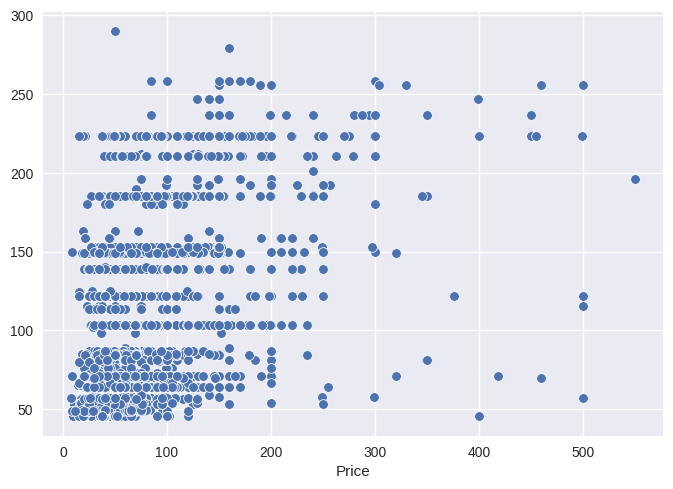

In [323]:
sns.scatterplot(x=y_val, y=y_val_pred_ADABoost)

### Gradient Boosting Machine (GBM)

In [324]:
model_GBM = GradientBoostingRegressor(random_state=42)
model_GBM.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [325]:
# Make predictions on the validation set
y_val_pred_GBM = model_GBM.predict(X_val)

In [326]:
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val, y_val_pred_GBM)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524
4,GBM,19.355174,1112.304792,33.351234,0.401387,0.534071


<Axes: xlabel='Price'>

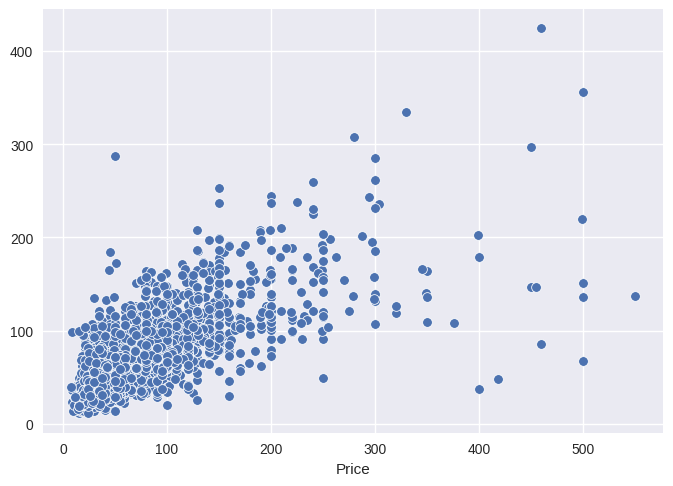

In [327]:
sns.scatterplot(x=y_val, y=y_val_pred_GBM)

### Support Vector Machine (SVM)

In [328]:
model_SVR = SVR()
model_SVR.fit(X_train, y_train)

SVR()

In [329]:
# Make predictions on the validation set
y_val_pred_SVR = model_SVR.predict(X_val)

In [330]:
regressionMetrics(y_val,y_val_pred_SVR)

{'MAE': 27.781145006312723,
 'MSE': 2414.48262771407,
 'RMSE': np.float64(49.13738523480945),
 'RMSLE': np.float64(0.565400342997207),
 'R²': -0.011393516291795747}

In [331]:
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_SVR)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524
4,GBM,19.355174,1112.304792,33.351234,0.401387,0.534071
5,SVM,27.781145,2414.482628,49.137385,0.565400,-0.011394


<Axes: xlabel='Price'>

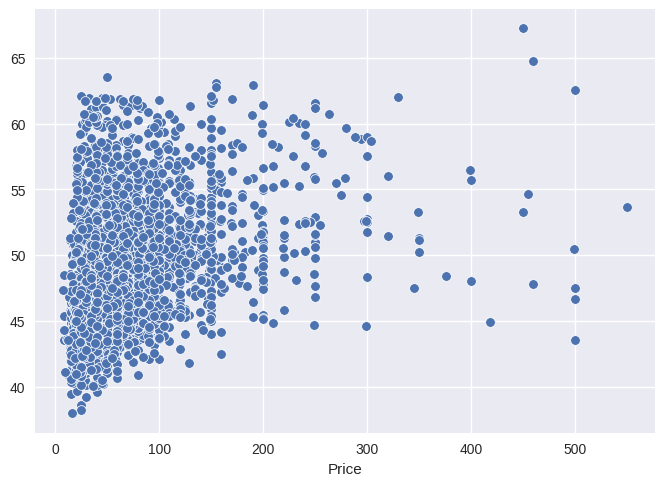

In [332]:
sns.scatterplot(x=y_val, y=y_val_pred_SVR)

### XGBoost Regressor

In [333]:
model_XGBoost= xgb.XGBRegressor()
model_XGBoost.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred_XGBoost = model_XGBoost.predict(X_val)

In [334]:
regressionMetrics(y_val,y_val_pred_XGBoost)

{'MAE': 18.89968109943881,
 'MSE': 1044.684340584502,
 'RMSE': np.float64(32.32157701264748),
 'RMSLE': np.float64(0.39290713285244827),
 'R²': 0.5623961189403681}

In [335]:
model_dict = {'model': "XGBoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_val,y_val_pred_XGBoost)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MAE,MSE,RMSE,RMSLE,R²
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524
4,GBM,19.355174,1112.304792,33.351234,0.401387,0.534071
5,SVM,27.781145,2414.482628,49.137385,0.565400,-0.011394
6,XGBoost,18.899681,1044.684341,32.321577,0.392907,0.562396


<Axes: xlabel='Price'>

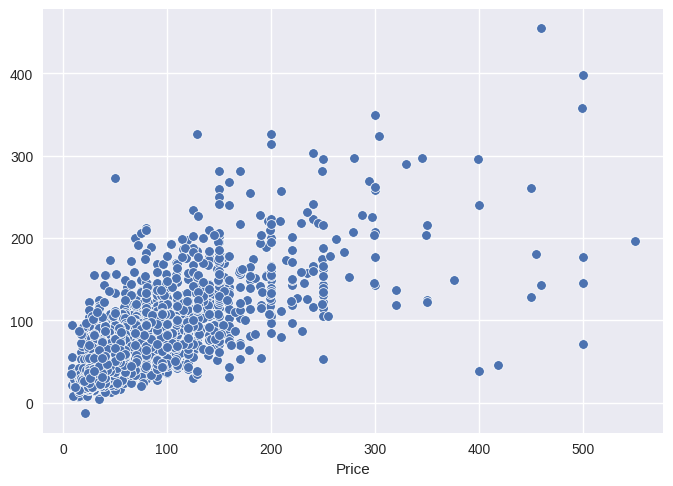

In [336]:
sns.scatterplot(x=y_val, y=y_val_pred_XGBoost)

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [337]:
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
6,XGBoost,18.899681,1044.684341,32.321577,0.392907,0.562396
4,GBM,19.355174,1112.304792,33.351234,0.401387,0.534071
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
5,SVM,27.781145,2414.482628,49.137385,0.565400,-0.011394
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524


## Hyperparameters and Finetuning

In [338]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

### Random Search: we decide which parameters and how (randomly)

In [339]:
%matplotlib inline

# Reduced number of options for each hyperparameter
n_estimators = [100, 200, 300]  # Fewer values for the number of trees
max_features = ['auto','sqrt']  #  # Number of features to consider at each split
max_depth = [10, 20, 30, 40, None]  # Fewer values for max depth
min_samples_split = [2, 5, 10]  # Keep essential options only
min_samples_leaf = [1, 2, 4]  # Reduced options for leaf samples
bootstrap = [True, False]  # Keep as is

# Create a lighter random grid
lighter_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(lighter_grid)
rf_random = RandomizedSearchCV(estimator=model_RFR, param_distributions=lighter_grid, n_iter=25, cv=3,
                               verbose=2, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

{'n_estimators': [100, 200, 300], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}
Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

In [340]:
rf_random.best_estimator_

RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                      min_samples_split=5, n_estimators=300, random_state=42)

In [341]:
def evaluate(model, test_features, y_test):
    predictions = model.predict(test_features)
    errors = abs(predictions - y_test)
    mae = 100 * np.mean(errors)
    print('Model Performance')
    print('Mean Absolute Error: {:0.4f}'.format(np.mean(errors)))
    # print('R^2: {:0.2f}'.format(metrics.r2_score(predictions, y_test)))
    return mae

#### Running base Model

In [342]:
base_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_val, y_val)

Model Performance
Mean Absolute Error: 19.8590


In [343]:
best_random = rf_random.best_estimator_
random_accuracy = evaluate(best_random, X_val, y_val)

Model Performance
Mean Absolute Error: 18.6670


#### Comparisson

In [344]:
print('Improvement of {:0.2f}%.'.format( 100 * (base_accuracy - random_accuracy) / base_accuracy))

Improvement of 6.00%.


Good improvment of 5.52% from the fine tuning when used with **RandomForestRegressor** model, so we can try use the tinued model instead of basic

## Model Evaluation

### Performance Metrics

Performance Metrics with the fine tuned Model

In [345]:
# make predictions on the validation set
y_val_pred_RFR_best_random = best_random.predict(X_val)

In [346]:
model_dict = {"model":"RandomForest_Tuned"}
model_dict.update(regressionMetrics(y_val, y_val_pred_RFR_best_random))
new_row = pd.DataFrame([model_dict])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,RandomForest_Tuned,18.666998,1059.935513,32.556651,0.389038,0.556008
6,XGBoost,18.899681,1044.684341,32.321577,0.392907,0.562396
4,GBM,19.355174,1112.304792,33.351234,0.401387,0.534071
2,RandomForest,19.859041,1178.198232,34.324892,0.409131,0.506469
0,LinearRegression,21.939204,1396.580656,37.370853,0.489283,0.414992
1,DecisionTree,27.210145,2504.026002,50.040244,0.545262,-0.048902
5,SVM,27.781145,2414.482628,49.137385,0.565400,-0.011394
3,ADABoost,31.358417,2171.176359,46.595883,0.585337,0.090524


After we added the tuned Random Forest Regressor to all metrics table , we can see it is a little better from XGBoost Model

### Validation with X_test, y_test

In [347]:
models_ = {"LinearRegression":model_LR,
           "DecisionTree":model_DTR,
           "RandomForest":model_RFR,
           "ADABoost":model_ADABoost,
           "GBM":model_GBM,
           "SVR":model_SVR,
           "XGBoost":model_XGBoost,
           "RandomForest_Tuned":best_random
           }
models_eval_list = pd.DataFrame(columns= ['model', 'MAE', 'MSE', 'RMSE', 'RMSLE', 'R²'])

In [348]:
for name, model in models_.items():
    print(model)
    y_test_pred = model.predict(X_test)
    # print(regressionMetrics(y_test, y_test_pred))
    model_dict = {"model":name}
    model_dict.update(regressionMetrics(y_test, y_test_pred))
    new_row = pd.DataFrame([model_dict])
    models_eval_list = pd.concat([models_eval_list, new_row], ignore_index=True)

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(random_state=42)
AdaBoostRegressor(random_state=42)
GradientBoostingRegressor(random_state=42)
SVR()
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)
RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt'

In [349]:
models_eval_list.sort_values('MAE')

,model,MAE,MSE,RMSE,RMSLE,R²
7,RandomForest_Tuned,18.524225,1007.805393,31.745951,0.384183,0.552648
6,XGBoost,19.148150,1059.772482,32.554147,0.397415,0.529580
4,GBM,19.241701,1072.216482,32.744717,0.395362,0.524057
2,RandomForest,19.447882,1094.715597,33.086487,0.401210,0.514069
0,LinearRegression,21.544881,1307.288950,36.156451,0.474543,0.419711
1,DecisionTree,26.540068,2309.488065,48.057133,0.536609,-0.025153
5,SVR,27.446614,2284.774569,47.799316,0.558585,-0.014183
3,ADABoost,30.464153,2038.064864,45.144932,0.567900,0.095329


## Store Objects States

In [350]:
import joblib

joblib.dump(model_LR,"/content/drive/My Drive/Airbnb/model_LR.pkl")
joblib.dump(model_DTR,"/content/drive/My Drive/Airbnb/model_DTR.pkl")
joblib.dump(model_RFR,"/content/drive/My Drive/Airbnb/model_RFR.pkl")
joblib.dump(model_ADABoost,"/content/drive/My Drive/Airbnb/model_ADABoost.pkl")
joblib.dump(model_GBM,"/content/drive/My Drive/Airbnb/model_GBM.pkl")
joblib.dump(model_SVR,"/content/drive/My Drive/Airbnb/model_SVR.pkl")
joblib.dump(model_XGBoost,"/content/drive/My Drive/Airbnb/model_XGBoost.pkl")
joblib.dump(best_random,"/content/drive/My Drive/Airbnb/best_random.pkl")

models_list.to_pickle("/content/drive/My Drive/Airbnb/models_selection_list.pkl")
df.to_pickle("/content/drive/My Drive/Airbnb/df_Model_Selection_Post.pkl")

In [351]:
# model_LR_ = joblib.load("/content/drive/My Drive/Airbnb/model_LR.pkl")